# 02 — Pré-processamento

Aplica as decisões do `01_eda.ipynb` (seção 11.7), monta o pipeline sklearn reproduzível e gera os splits 70/15/15 estratificados em `data/processed/`.

**Toda a lógica vive em `src/churn/data/preprocessing.py`** — este notebook só importa, executa e documenta as decisões com saídas reais. Mudanças no pipeline são feitas no módulo, nunca aqui.

## 1. Setup

In [1]:
import logging

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn.config import (
    LEAKAGE_COLUMNS,
    PROCESSED_DATA_DIR,
    SEED,
    TARGET_COLUMN,
    TEST_SIZE,
    VAL_SIZE,
)
from churn.data.loader import load_raw_data
from churn.data.preprocessing import (
    BINARY_COLUMNS,
    DROP_COLUMNS,
    MULTICLASS_COLUMNS,
    NO_INTERNET_SERVICE_COLUMNS,
    NUMERIC_COLUMNS,
    build_preprocessing_pipeline,
    clean_raw,
    split_features_target,
    stratified_split,
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s [%(name)s] %(message)s')
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

## 2. Decisões herdadas da EDA (sumário executivo)

Cada item abaixo está justificado em `01_eda.ipynb` seção 11.

**Drop (12 colunas):**

| Categoria | Colunas | Motivo |
|---|---|---|
| Leakage | `Churn Label`, `Churn Score`, `Churn Reason` | Derivam do target |
| Identificadores | `CustomerID`, `Count` | Único por linha / constante |
| Geográficas | `Country`, `State`, `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude` | Sem variabilidade ou \|corr\| ~ 0 |

**Manter mesmo com sinal fraco:**

- `Gender` (Cramér's V = 0,008) — mantida para análise de viés no Model Card.
- `Phone Service` (0,01), `Multiple Lines` (0,04) — sinal fraco mas não-zero; validar relevância com ablation pós-baseline.
- `CLTV` (AUC isolada = 0,58) — sinal genuíno, não é leak.

**Tratamentos:**

- `Total Charges` → coerção `object → float64`, imputar `0.0` nas 11 linhas em branco (todas com `Tenure Months == 0`).
- Colunas com `"No internet service"` (6) → colapsar em `"No"` para evitar 6 dummies colineares de "sem internet". A informação fica em `Internet Service`.
- `Multiple Lines` com `"No phone service"` → colapsar em `"No"` pelo mesmo motivo.

In [2]:
print('Leakage columns dropped:', list(LEAKAGE_COLUMNS))
print('Other drops:', list(DROP_COLUMNS))
print()
print('Numeric (StandardScaler):', list(NUMERIC_COLUMNS))
print('Binary (OneHot drop_if_binary -> 1 col):', list(BINARY_COLUMNS))
print('Multi-class (OneHot keep all):', list(MULTICLASS_COLUMNS))
print()
print('Collapse "No internet service" -> "No" on:', list(NO_INTERNET_SERVICE_COLUMNS))

Leakage columns dropped: ['Churn Label', 'Churn Score', 'Churn Reason']
Other drops: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude']

Numeric (StandardScaler): ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
Binary (OneHot drop_if_binary -> 1 col): ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Multiple Lines']
Multi-class (OneHot keep all): ['Contract', 'Internet Service', 'Payment Method']

Collapse "No internet service" -> "No" on: ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']


## 3. Cleaning — `clean_raw`

In [3]:
df_raw = load_raw_data()
print(f'Raw shape: {df_raw.shape}')

INFO [churn.data.loader] Loading raw data from D:\Projs\Churn-Prediction-ANN\data\raw\raw_data.xlsx


INFO [churn.data.loader] Loaded raw data: 7043 rows x 33 columns


INFO [churn.data.loader] Raw data schema validated successfully


Raw shape: (7043, 33)


In [4]:
df_clean = clean_raw(df_raw)
print(f'Clean shape: {df_clean.shape}')
print(f'Columns dropped: {df_raw.shape[1] - df_clean.shape[1]}')
print(f'Columns kept: {list(df_clean.columns)}')

INFO [churn.data.preprocessing] Dropped 12 columns (leakage + identifiers + geo)


INFO [churn.data.preprocessing] Coerced 'Total Charges' to float; imputed 11 blank rows with 0.0


INFO [churn.data.preprocessing] Collapsed 'No internet service' on 6 cols and 'No phone service' on 1 col


Clean shape: (7043, 21)
Columns dropped: 12
Columns kept: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


### 3.1 Verificação — `Total Charges` virou `float`

Sanity: as 11 linhas problemáticas viraram `0.0`.

In [5]:
tc_raw = df_raw['Total Charges']
tc_clean = df_clean['Total Charges']
print(f'dtype antes : {tc_raw.dtype}')
print(f'dtype depois: {tc_clean.dtype}')

blank_raw = pd.to_numeric(tc_raw, errors='coerce').isna()
imputed = df_clean.loc[blank_raw, ['Tenure Months', 'Total Charges', TARGET_COLUMN]]
print(f'\n{blank_raw.sum()} linhas imputadas (todas com Tenure Months == 0):')
imputed

dtype antes : object
dtype depois: float64

11 linhas imputadas (todas com Tenure Months == 0):


,Tenure Months,Total Charges,Churn Value
2234,0,0.0,0
2438,0,0.0,0
2568,0,0.0,0
2667,0,0.0,0
2856,0,0.0,0
4331,0,0.0,0
4687,0,0.0,0
5104,0,0.0,0
5719,0,0.0,0
6772,0,0.0,0


### 3.2 Verificação — colapso de "No internet service" e "No phone service"

In [6]:
before = pd.DataFrame({col: sorted(df_raw[col].unique()) for col in (*NO_INTERNET_SERVICE_COLUMNS, 'Multiple Lines')}).T
before.columns = [f'cat {i}' for i in range(before.shape[1])]
before.index.name = 'antes'
before

,cat 0,cat 1,cat 2
antes,,,
Online Security,No,No internet service,Yes
Online Backup,No,No internet service,Yes
Device Protection,No,No internet service,Yes
Tech Support,No,No internet service,Yes
Streaming TV,No,No internet service,Yes
Streaming Movies,No,No internet service,Yes
Multiple Lines,No,No phone service,Yes


In [7]:
after = pd.DataFrame({col: sorted(df_clean[col].unique()) for col in (*NO_INTERNET_SERVICE_COLUMNS, 'Multiple Lines')}).T
after.columns = [f'cat {i}' for i in range(after.shape[1])]
after.index.name = 'depois'
after

,cat 0,cat 1
depois,,
Online Security,No,Yes
Online Backup,No,Yes
Device Protection,No,Yes
Tech Support,No,Yes
Streaming TV,No,Yes
Streaming Movies,No,Yes
Multiple Lines,No,Yes


### 3.3 Verificação — distribuições preservadas

O colapso muda **rótulos**, não **registros**. A contagem de cada nível antes do colapso (`Yes` + `No internet service` virando `No`) deve explicar a soma do `No` depois.

In [8]:
rows = []
for col in NO_INTERNET_SERVICE_COLUMNS:
    raw_counts = df_raw[col].value_counts()
    clean_counts = df_clean[col].value_counts()
    rows.append({
        'col': col,
        'raw_No': raw_counts.get('No', 0),
        'raw_NoInternet': raw_counts.get('No internet service', 0),
        'raw_Yes': raw_counts.get('Yes', 0),
        'clean_No': clean_counts.get('No', 0),
        'clean_Yes': clean_counts.get('Yes', 0),
        'consistent': clean_counts.get('No', 0) == raw_counts.get('No', 0) + raw_counts.get('No internet service', 0),
    })
pd.DataFrame(rows)

,col,raw_No,raw_NoInternet,raw_Yes,clean_No,clean_Yes,consistent
0,Online Security,3498,1526,2019,5024,2019,True
1,Online Backup,3088,1526,2429,4614,2429,True
2,Device Protection,3095,1526,2422,4621,2422,True
3,Tech Support,3473,1526,2044,4999,2044,True
4,Streaming TV,2810,1526,2707,4336,2707,True
5,Streaming Movies,2785,1526,2732,4311,2732,True


## 4. Split estratificado 70 / 15 / 15

Função `stratified_split` aplica `train_test_split` em duas etapas, estratificando pelo target em ambas. Seed fixa (`SEED = 42`).

In [9]:
X, y = split_features_target(df_clean)
print(f'X shape: {X.shape} | y mean: {y.mean():.4f}')
print(f'TEST_SIZE: {TEST_SIZE} | VAL_SIZE: {VAL_SIZE} | SEED: {SEED}')

X shape: (7043, 20) | y mean: 0.2654
TEST_SIZE: 0.15 | VAL_SIZE: 0.15 | SEED: 42


In [10]:
splits = stratified_split(X, y)

summary = pd.DataFrame({
    'set':     ['train', 'val', 'test'],
    'n':       [len(splits.X_train), len(splits.X_val), len(splits.X_test)],
    'pct':     [len(splits.X_train) / len(X), len(splits.X_val) / len(X), len(splits.X_test) / len(X)],
    'target_rate': [splits.y_train.mean(), splits.y_val.mean(), splits.y_test.mean()],
}).round(4)
summary['pct'] = (summary['pct'] * 100).round(2)
summary

INFO [churn.data.preprocessing] Stratified split: train=4929 val=1057 test=1057 (target rates: 0.2654 / 0.2658 / 0.2649)


,set,n,pct,target_rate
0,train,4929,69.98,0.2654
1,val,1057,15.01,0.2658
2,test,1057,15.01,0.2649


### 4.1 Verificação visual — proporções de churn por conjunto

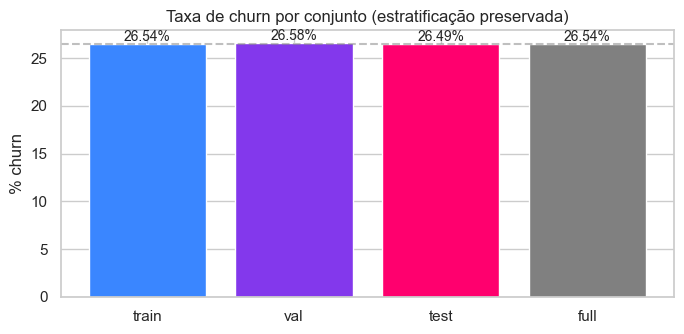

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.5))
rates = [splits.y_train.mean(), splits.y_val.mean(), splits.y_test.mean(), y.mean()]
labels = ['train', 'val', 'test', 'full']
colors = ['#3a86ff', '#8338ec', '#ff006e', 'gray']
bars = ax.bar(labels, [r * 100 for r in rates], color=colors)
for bar, r in zip(bars, rates):
    ax.annotate(f'{r*100:.2f}%', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.set_ylabel('% churn')
ax.set_title('Taxa de churn por conjunto (estratificação preservada)')
ax.axhline(y.mean() * 100, ls='--', color='gray', alpha=0.5)
plt.tight_layout(); plt.show()

## 5. Build do pipeline sklearn

In [12]:
preprocessor = build_preprocessing_pipeline()
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### 5.1 Estrutura

- `num` → `StandardScaler` em 4 numéricas.
- `cat` → `OneHotEncoder(drop='if_binary', handle_unknown='ignore')` em 13 binárias + 3 multi-class. Binárias colapsam em 1 col (drop_if_binary), multi-class mantém todos os níveis.
- `remainder='drop'` — defensivo: qualquer coluna não declarada some, uma quebra futura de schema fica explícita.

## 6. Fit no train, transform em todos

**Fit somente no train** (evita data leakage do val/test no scaler e nas categorias do OneHot). `transform` é aplicado em val/test.

In [13]:
X_train_proc = preprocessor.fit_transform(splits.X_train)
X_val_proc = preprocessor.transform(splits.X_val)
X_test_proc = preprocessor.transform(splits.X_test)

feature_names = preprocessor.get_feature_names_out()
print(f'X_train_proc: {X_train_proc.shape}')
print(f'X_val_proc:   {X_val_proc.shape}')
print(f'X_test_proc:  {X_test_proc.shape}')
print(f'\n{len(feature_names)} features de saída:')
for i, name in enumerate(feature_names):
    print(f'  [{i:2d}] {name}')

X_train_proc: (4929, 27)
X_val_proc:   (1057, 27)
X_test_proc:  (1057, 27)

27 features de saída:
  [ 0] Tenure Months
  [ 1] Monthly Charges
  [ 2] Total Charges
  [ 3] CLTV
  [ 4] Gender_Male
  [ 5] Senior Citizen_Yes
  [ 6] Partner_Yes
  [ 7] Dependents_Yes
  [ 8] Phone Service_Yes
  [ 9] Paperless Billing_Yes
  [10] Online Security_Yes
  [11] Online Backup_Yes
  [12] Device Protection_Yes
  [13] Tech Support_Yes
  [14] Streaming TV_Yes
  [15] Streaming Movies_Yes
  [16] Multiple Lines_Yes
  [17] Contract_Month-to-month
  [18] Contract_One year
  [19] Contract_Two year
  [20] Internet Service_DSL
  [21] Internet Service_Fiber optic
  [22] Internet Service_No
  [23] Payment Method_Bank transfer (automatic)
  [24] Payment Method_Credit card (automatic)
  [25] Payment Method_Electronic check
  [26] Payment Method_Mailed check


### 6.1 Sanity — sem NaN, ranges esperados

In [14]:
print('NaN no train_proc:', bool(np.isnan(X_train_proc).any()))
print('NaN no val_proc:  ', bool(np.isnan(X_val_proc).any()))
print('NaN no test_proc: ', bool(np.isnan(X_test_proc).any()))

X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
stats = X_train_df.describe().T[['mean', 'std', 'min', 'max']].round(3)
stats.head(10)  # primeiras 10 features (numéricas + algumas binárias)

NaN no train_proc: False
NaN no val_proc:   False
NaN no test_proc:  False


,mean,std,min,max
Tenure Months,-0.000,1.000,-1.313,1.600
Monthly Charges,-0.000,1.000,-1.531,1.785
Total Charges,0.000,1.000,-1.005,2.807
CLTV,0.000,1.000,-2.034,1.770
Gender_Male,0.505,0.500,0.000,1.000
Senior Citizen_Yes,0.159,0.365,0.000,1.000
Partner_Yes,0.480,0.500,0.000,1.000
Dependents_Yes,0.232,0.422,0.000,1.000
Phone Service_Yes,0.901,0.299,0.000,1.000
Paperless Billing_Yes,0.594,0.491,0.000,1.000


Numéricas (`Tenure Months`, `Monthly Charges`, `Total Charges`, `CLTV`) devem ter `mean ≈ 0` e `std ≈ 1` por construção do `StandardScaler`. Binárias e dummies estão em `[0, 1]` com `mean = freq da categoria`.

## 7. Persistência em `data/processed/`

Salvamos **dois artefatos** para permitir tanto uso direto (matrizes prontas) quanto refit (mantém os splits limpos para experimentos alternativos):

- `train.parquet` / `val.parquet` / `test.parquet` — splits **limpos** (pós-`clean_raw`, pré-pipeline) com a target. Fonte de verdade.
- `preprocessor.joblib` — `ColumnTransformer` **fit no train**, pronto para `transform` no val/test/inferência.

(Os parquets ficam ignorados pelo git — `.gitignore` cobre `data/processed/`.)

In [15]:
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

for name, X_split, y_split in [
    ('train', splits.X_train, splits.y_train),
    ('val',   splits.X_val,   splits.y_val),
    ('test',  splits.X_test,  splits.y_test),
]:
    out = X_split.copy()
    out[TARGET_COLUMN] = y_split.values
    out_path = PROCESSED_DATA_DIR / f'{name}.parquet'
    out.to_parquet(out_path, index=False)
    print(f'Wrote {out_path} | shape={out.shape}')

preproc_path = PROCESSED_DATA_DIR / 'preprocessor.joblib'
joblib.dump(preprocessor, preproc_path)
print(f'Wrote {preproc_path}')

Wrote D:\Projs\Churn-Prediction-ANN\data\processed\train.parquet | shape=(4929, 21)
Wrote D:\Projs\Churn-Prediction-ANN\data\processed\val.parquet | shape=(1057, 21)
Wrote D:\Projs\Churn-Prediction-ANN\data\processed\test.parquet | shape=(1057, 21)
Wrote D:\Projs\Churn-Prediction-ANN\data\processed\preprocessor.joblib


## 8. Sanity checks finais

### 8.1 Reload — formato consistente

In [16]:
reloaded = pd.read_parquet(PROCESSED_DATA_DIR / 'train.parquet')
preproc_reloaded = joblib.load(PROCESSED_DATA_DIR / 'preprocessor.joblib')
print(f'Reloaded train shape: {reloaded.shape} (cols: {reloaded.shape[1]} = 20 features + 1 target)')
print(f'Target balance preserved: {reloaded[TARGET_COLUMN].mean():.4f}')
print(f'Preprocessor reloaded type: {type(preproc_reloaded).__name__}')
X_check = preproc_reloaded.transform(reloaded.drop(columns=[TARGET_COLUMN]))
print(f'Re-transform shape: {X_check.shape}')

Reloaded train shape: (4929, 21) (cols: 21 = 20 features + 1 target)
Target balance preserved: 0.2654
Preprocessor reloaded type: ColumnTransformer
Re-transform shape: (4929, 27)


### 8.2 Determinismo — mesmo seed produz o mesmo split

In [17]:
X2, y2 = split_features_target(clean_raw(load_raw_data()))
splits2 = stratified_split(X2, y2)

same_train = (splits.X_train.index == splits2.X_train.index).all()
same_val = (splits.X_val.index == splits2.X_val.index).all()
same_test = (splits.X_test.index == splits2.X_test.index).all()
print(f'Same train indices: {same_train}')
print(f'Same val indices:   {same_val}')
print(f'Same test indices:  {same_test}')
assert same_train and same_val and same_test, 'Pipeline is not deterministic!'

INFO [churn.data.loader] Loading raw data from D:\Projs\Churn-Prediction-ANN\data\raw\raw_data.xlsx


INFO [churn.data.loader] Loaded raw data: 7043 rows x 33 columns


INFO [churn.data.loader] Raw data schema validated successfully


INFO [churn.data.preprocessing] Dropped 12 columns (leakage + identifiers + geo)


INFO [churn.data.preprocessing] Coerced 'Total Charges' to float; imputed 11 blank rows with 0.0


INFO [churn.data.preprocessing] Collapsed 'No internet service' on 6 cols and 'No phone service' on 1 col


INFO [churn.data.preprocessing] Stratified split: train=4929 val=1057 test=1057 (target rates: 0.2654 / 0.2658 / 0.2649)


Same train indices: True
Same val indices:   True
Same test indices:  True


### 8.3 Resumo final

- ✅ Cleaning: 33 → 21 colunas (12 dropadas, 11 imputações em `Total Charges`).
- ✅ Split estratificado 70/15/15 com target rate `0.265 ± 0.001` em todos.
- ✅ Pipeline: 20 features de input → **27 features de output** (4 escaladas + 13 binárias + 10 dummies multi-class).
- ✅ Sem NaN, ranges consistentes, determinístico.
- ✅ Artefatos em `data/processed/` (gitignored).

Próximo passo: **fase 2** — baselines sklearn em `03_baseline.ipynb` consumindo os artefatos persistidos.